# Notebook Colab — MLPClassifier con Pipeline
**Clasificación con distintas arquitecturas MLP (número de neuronas y capas)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier


In [2]:
# CARGAMOS UN DATASET WINE QUALITY (RED)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=";")
df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# CLASIFICACION BINARIA

df["label"] = (df["quality"] >= 7).astype(int)  # 1 = bueno, 0 = malo

X = df.drop(["quality", "label"], axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pre_scale = StandardScaler()


In [8]:
# DEFINIMOS DISTINTAS ARQUITECTURAS PARA LA RED NEURONAL

configuraciones = [
    (3,),               # Muy pequeña → bajo accuracy
    (8,),               # Pequeña
    (32,),              # Mediana
    (64,),              # Gran capacidad
    (128,),             # Muy grande

    (16, 8),            # Dos capas pequeñas
    (64, 32),           # Dos capas grandes
    (128, 64),          # Dos capas muy grandes

    (256, 128, 64),     # Tres capas profundas
    (512, 256, 128),    # Extremadamente grande
]


In [9]:
# ENTRENAMOS LA RED CON LAS DISTINTAS CONFIGURACIONES


resultados = []

for hidden in configuraciones:
    print("="*60)
    print(f"Entrenando arquitectura: {hidden}")

    mlp = Pipeline([
        ('pre', pre_scale),
        ('clf', MLPClassifier(
            hidden_layer_sizes=hidden,
            max_iter=500,
            random_state=46))
    ])

    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    resultados.append((hidden, acc))

    print(f"Accuracy: {acc:.4f}")


Entrenando arquitectura: (3,)
Accuracy: 0.8969
Entrenando arquitectura: (8,)
Accuracy: 0.9000
Entrenando arquitectura: (32,)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9156
Entrenando arquitectura: (64,)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9156
Entrenando arquitectura: (128,)


...

Accuracy: 0.9187
Entrenando arquitectura: (16, 8)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9125
Entrenando arquitectura: (64, 32)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.9313
Entrenando arquitectura: (128, 64)
Accuracy: 0.9250
Entrenando arquitectura: (256, 128, 64)
Accuracy: 0.9250
Entrenando arquitectura: (512, 256, 128)
Accuracy: 0.9219


In [10]:
# RESULTADOS
#


df_res = pd.DataFrame(resultados, columns=["Arquitectura", "Accuracy"])
df_res


,Arquitectura,Accuracy
0,"(3,)",0.896875
1,"(8,)",0.900000
2,"(32,)",0.915625
3,"(64,)",0.915625
4,"(128,)",0.918750
5,"(16, 8)",0.912500
6,"(64, 32)",0.931250
7,"(128, 64)",0.925000
8,"(256, 128, 64)",0.925000
9,"(512, 256, 128)",0.921875


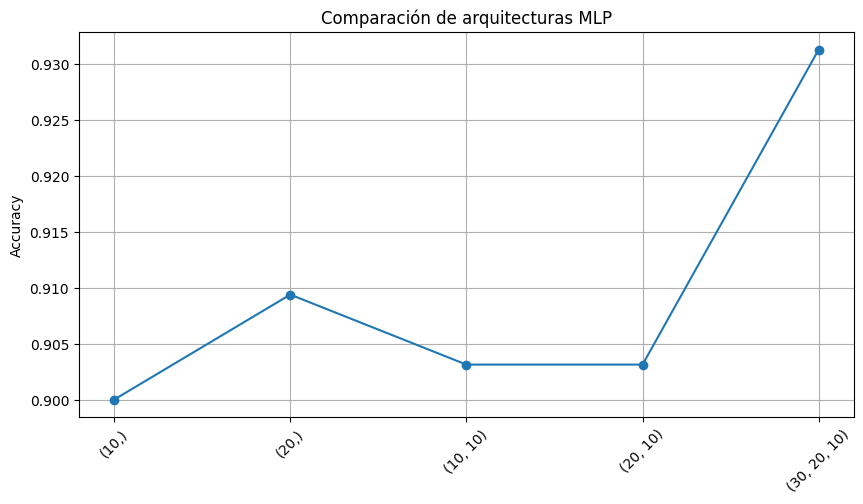

In [7]:
plt.figure(figsize=(12,5))
plt.plot(df_res["Accuracy"], marker="o")
plt.xticks(
    range(len(df_res)),
    [str(a) for a in df_res["Arquitectura"]],
    rotation=45
)
plt.title("Comparación de arquitecturas MLP — Wine Quality")
plt.ylabel("Accuracy")
plt.xlabel("Arquitectura")
plt.grid(True)
plt.show()
